In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from leela_interp.core.effect_study import *
from leela_interp.core.alternative_moves import *
from leela_interp.core.double_branch import *
from leela_interp.core.fifth_move_study import *
from leela_interp.core.checkmate_study import *
from leela_interp.core.general_study import *
from leela_interp.core.ablation_study import AblationStudy
from leela_interp.core.probing_study import ProbingStudy
from leela_interp.core.double_attention_study import *
import subprocess
# Disable FutureWarning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
#device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device("cpu")
model = Lc0sight("lc0.onnx", device=device)

Using device: cpu


# 9th move analysis

## Residual stream

In [6]:
# general_study = GeneralStudy(puzzlename="pv9", load_all=True)
# general_study.find_result_sets(include_starting=False, n_examples=10)
# general_study.export_puzzle_set_info()

In [9]:
study = CheckmateStudy(puzzlename="pv9", load_all=False)

/home/dcruz/Pivotal/leela-interp/src/leela_interp/core/checkmate_study.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", title=f"Set {'M' if mate else 'N'}{row_col[2]}", fontsize="small")
/home/dcruz/Pivotal/leela-interp/src/leela_interp/core/checkmate_study.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", title=f"Set {'M' if mate else 'N'}{row_col[2]}", fontsize="small")
/home/dcruz/Pivotal/leela-interp/src/leela_interp/core/checkmate_study.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", title=f"Set {'M' if mate else

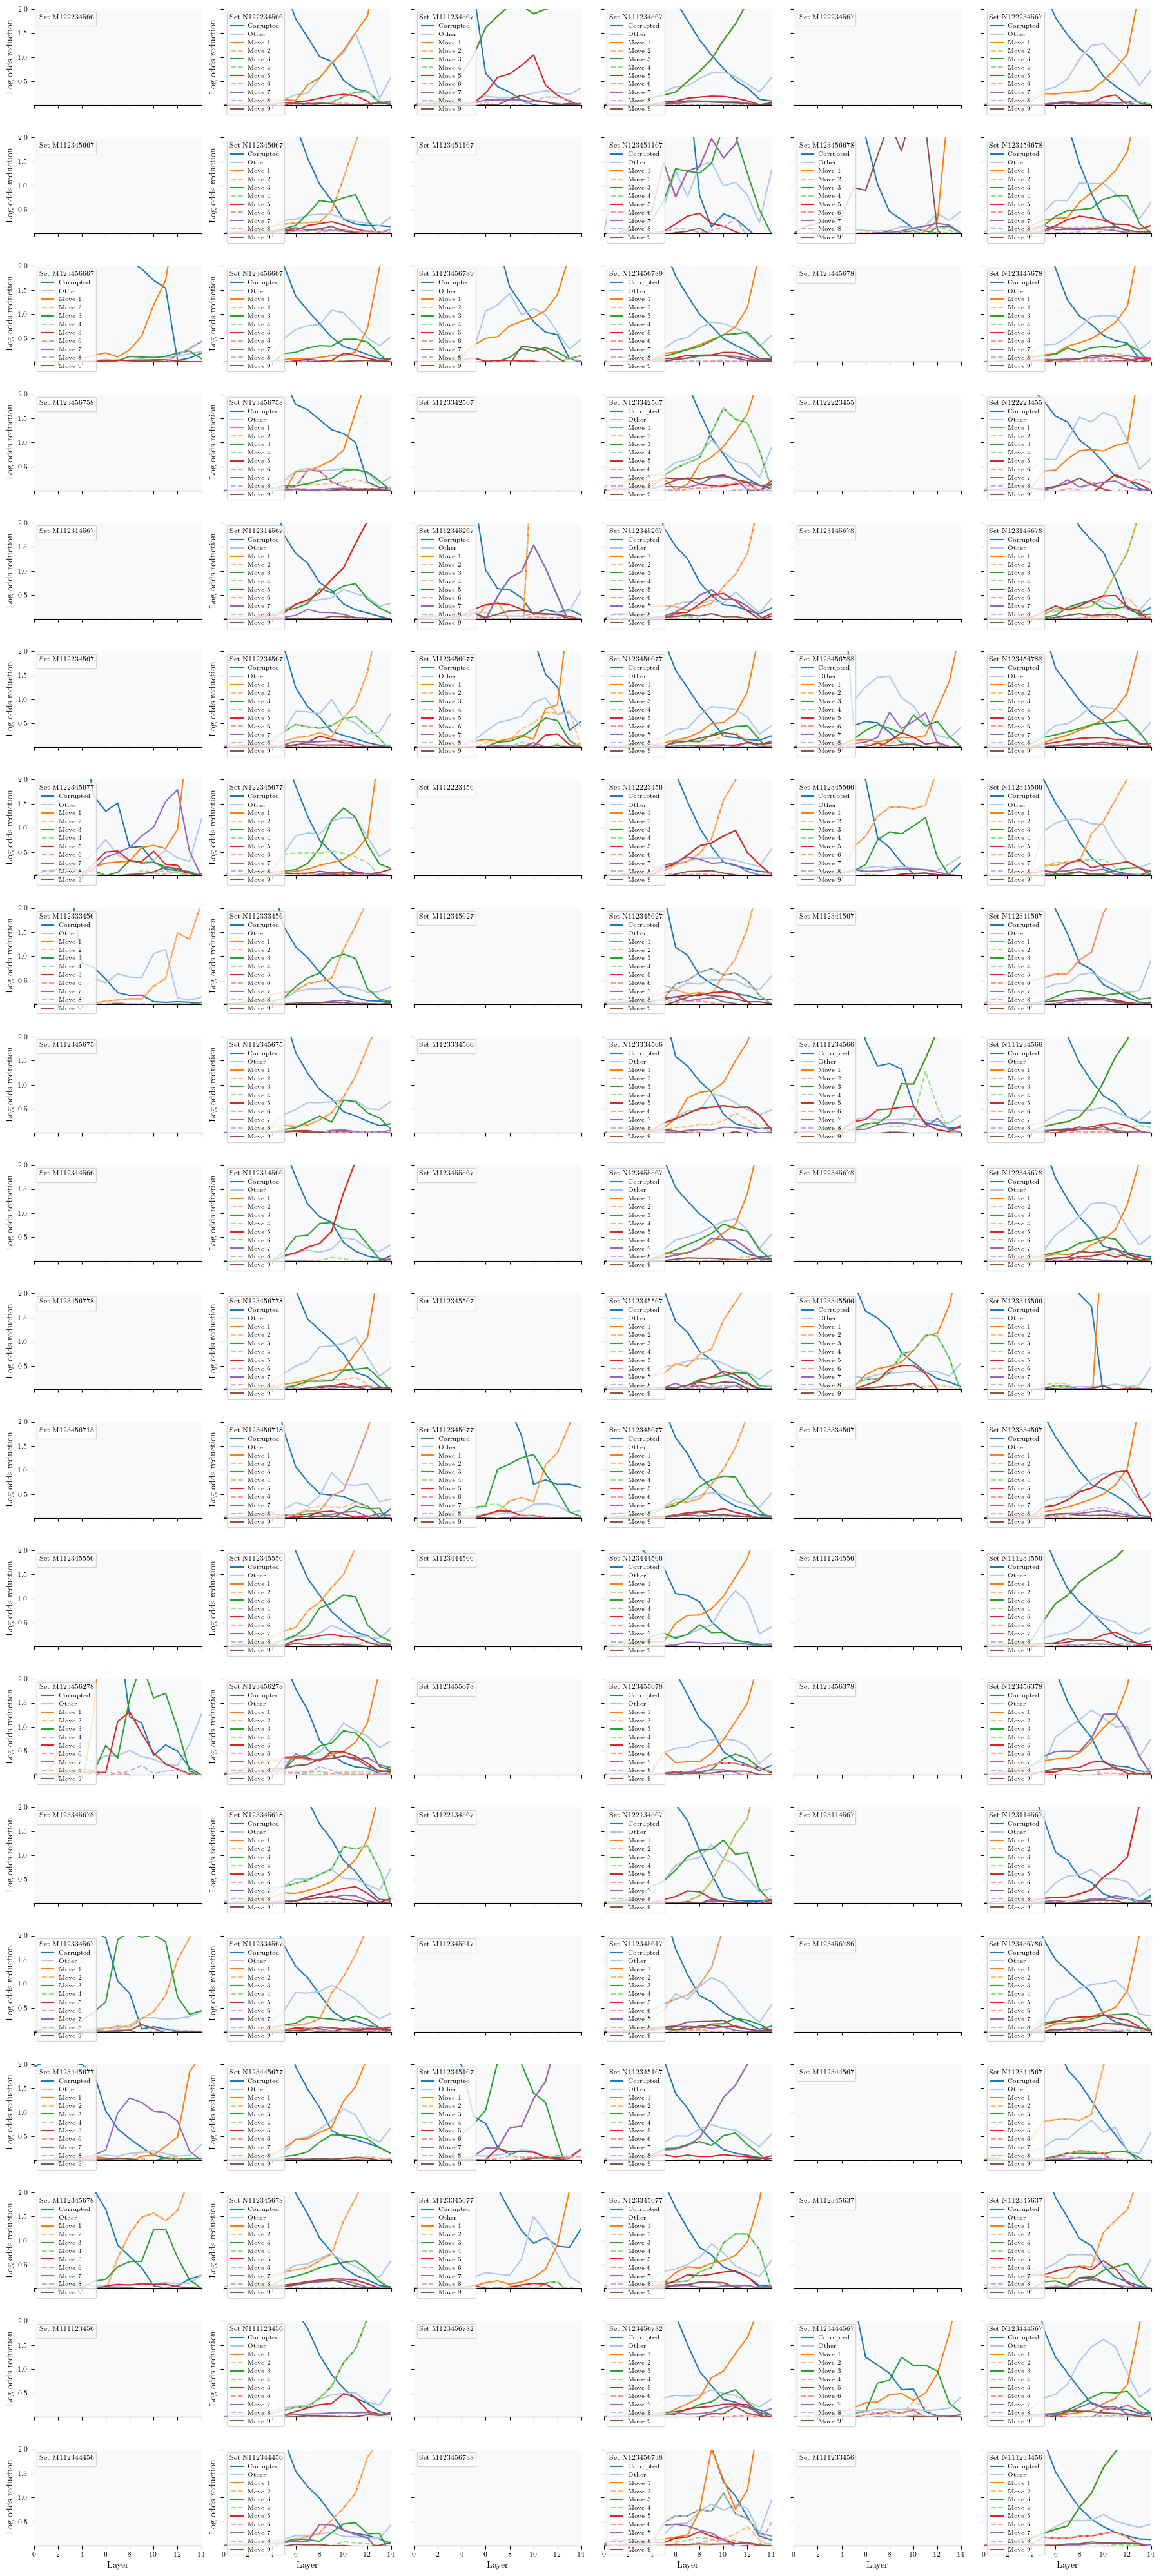

<Figure size 640x480 with 0 Axes>

In [10]:
possibilities = study.get_possibility_list('n', lengths=[9])
study.plot_residual_effects_grid('n', possibilities, n_cols=3, filename="paper_residual_effects_9_checkmate", y_max=2, plot_ci=False)

## Attention heads

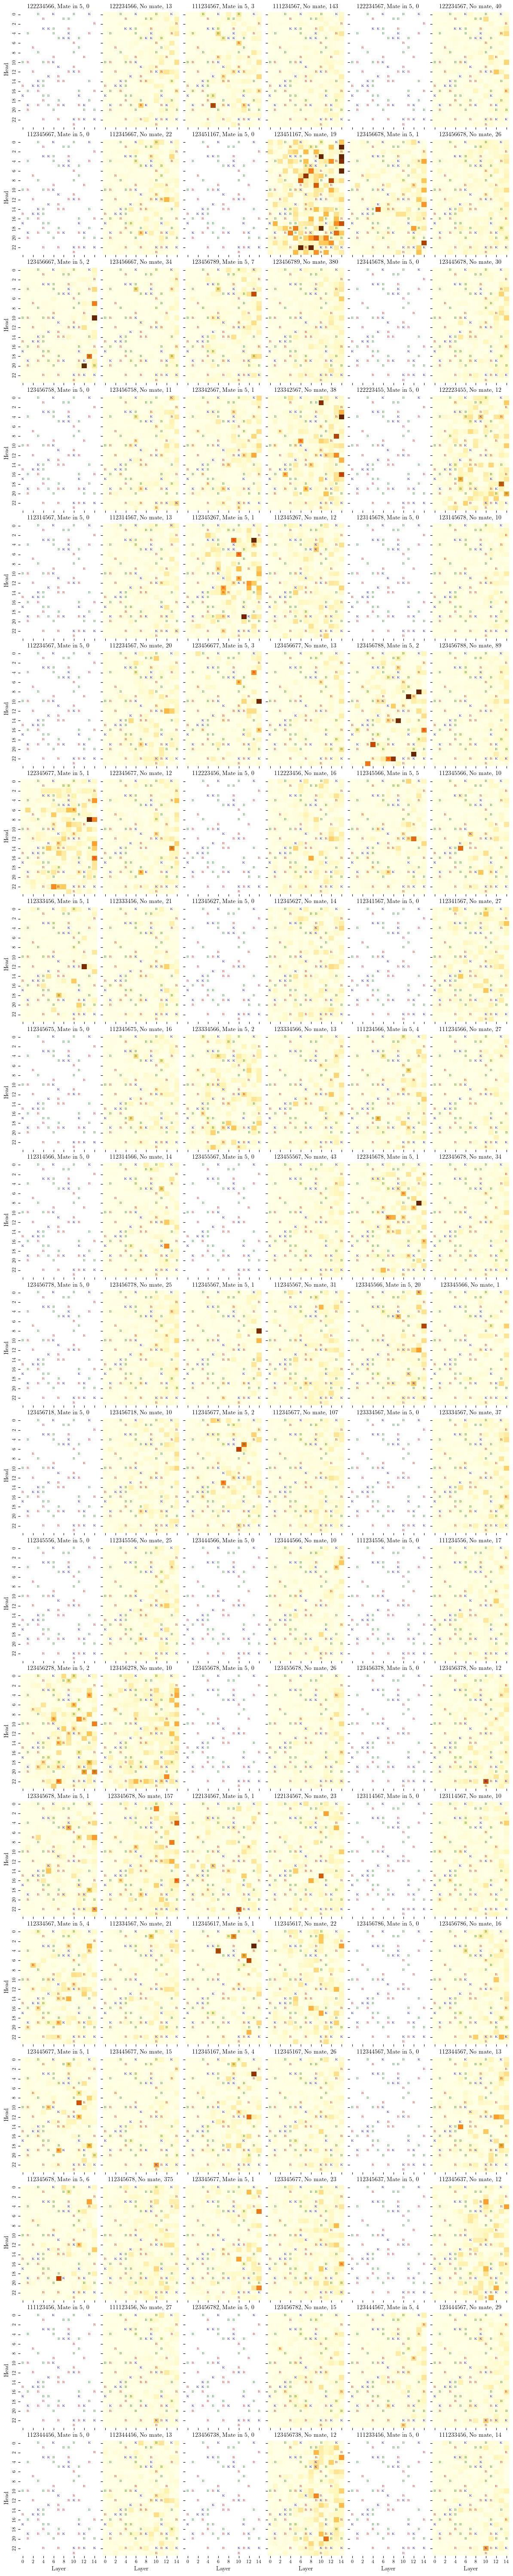

<Figure size 640x480 with 0 Axes>

In [11]:
possibilities = study.get_possibility_list('n', lengths=[9])
study.plot_attention_grid('n', possibilities, n_cols=3, filename="paper_attention_heads_9_checkmate", vmax=0.73)

In [12]:
[(possibility, len(study.puzzle_sets['n'][possibility])) for possibility in possibilities]

[('122234566', 13),
 ('111234567', 146),
 ('122234567', 40),
 ('112345667', 22),
 ('123451167', 19),
 ('123456678', 27),
 ('123456667', 36),
 ('123456789', 387),
 ('123445678', 30),
 ('123456758', 11),
 ('123342567', 39),
 ('122223455', 12),
 ('112314567', 13),
 ('112345267', 13),
 ('123145678', 10),
 ('112234567', 20),
 ('123456677', 16),
 ('123456788', 91),
 ('122345677', 13),
 ('112223456', 16),
 ('112345566', 15),
 ('112333456', 22),
 ('112345627', 14),
 ('112341567', 27),
 ('112345675', 16),
 ('123334566', 15),
 ('111234566', 31),
 ('112314566', 14),
 ('123455567', 43),
 ('122345678', 35),
 ('123456778', 25),
 ('112345567', 32),
 ('123345566', 21),
 ('123456718', 10),
 ('112345677', 109),
 ('123334567', 37),
 ('112345556', 25),
 ('123444566', 10),
 ('111234556', 17),
 ('123456278', 12),
 ('123455678', 26),
 ('123456378', 12),
 ('123345678', 158),
 ('122134567', 24),
 ('123114567', 10),
 ('112334567', 25),
 ('112345617', 23),
 ('123456786', 16),
 ('123445677', 16),
 ('112345167', 3

In [24]:
# import subprocess

# ablation_configs = [
#     ('L12H12', "1112345"),
#     ('L12H12', "1111234"),
# ]

# for config in ablation_configs:
#     layer_head, puzzle = config
#     layer = layer_head[1:3]  # Extract layer number
#     head = layer_head[4:]    # Extract head number
    
#     command = f"python3 scripts/run_single_head.py --filename interesting_puzzles_pv7_n_{puzzle} --layer {layer} --head {head} --device cuda --main"
    
#     print(f"Running command: {command}")
#     subprocess.run(command, shell=True)
#     print("Command completed.\n")

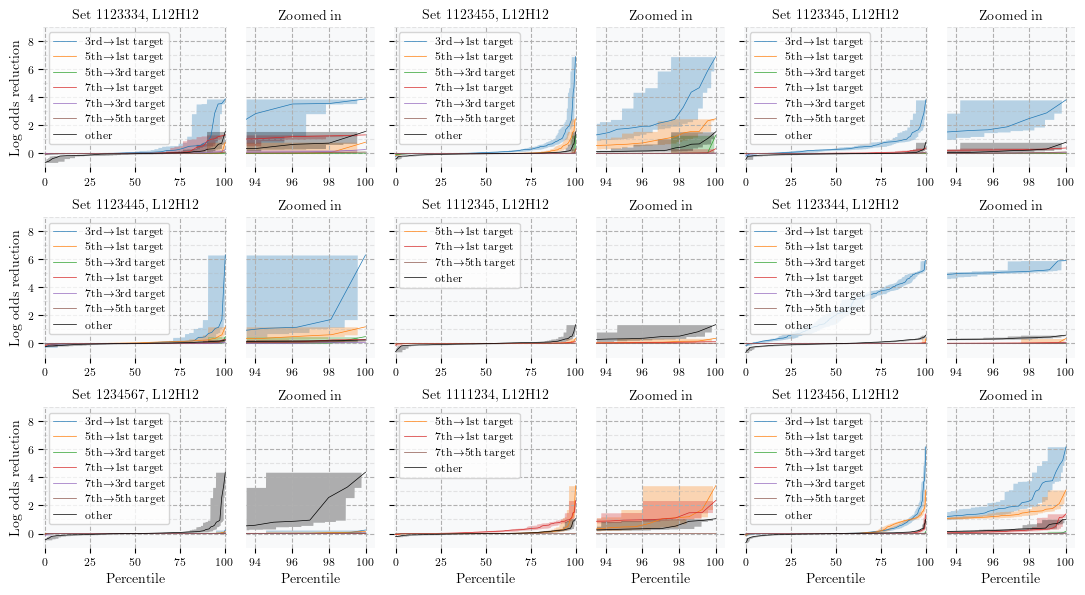

In [15]:
ablation_study = AblationStudy(folder_name="")
ablation_configs = [
    ('L12H12', "1123334"),
    ('L12H12', "1123455"),
    ('L12H12', "1123345"),
    ('L12H12', "1123445"),
    ('L12H12', "1112345"),
    ('L12H12', "1123344"),
    ('L12H12', "1234567"),
    ('L12H12', "1111234"),
    ('L12H12', "1123456")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=3, filename="paper_ablation_effects_7_L12H12", tag='pv7_n')

## Probing

In [ ]:
for possibility in possibilities:

    command = f"python3 scripts/probing.py --filename interesting_puzzles_pv7_n_{possibility} --main --random_model --n_seeds 5 --max_goal_square 7"
    
    print(f"Running command: {command}")
    subprocess.run(command, shell=True)
    print("Command completed.\n")

51


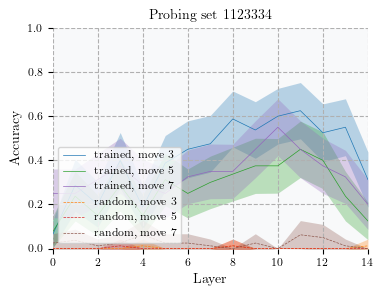

224


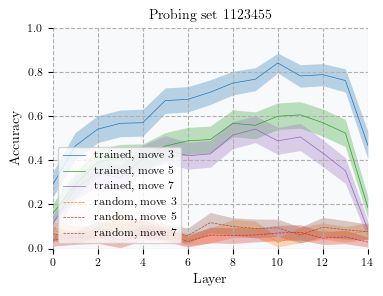

94


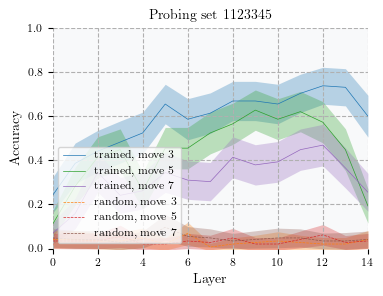

54


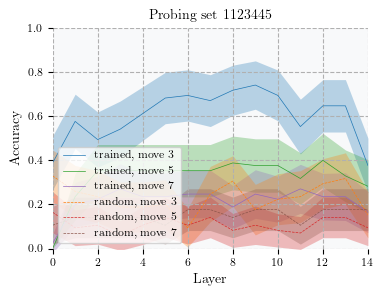

101


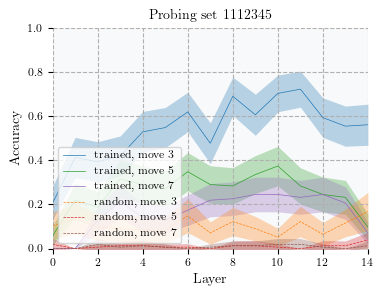

223


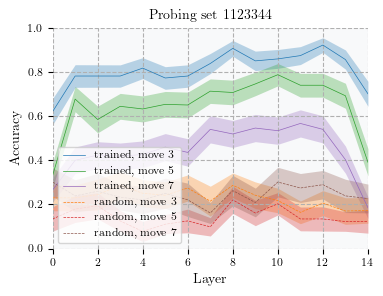

100


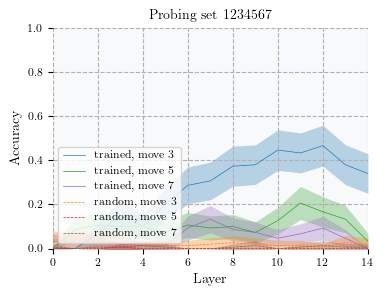

137


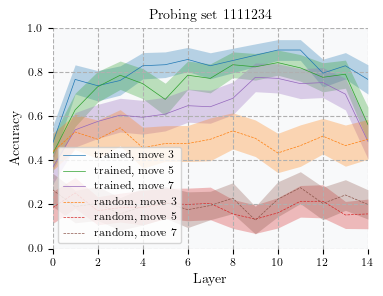

541


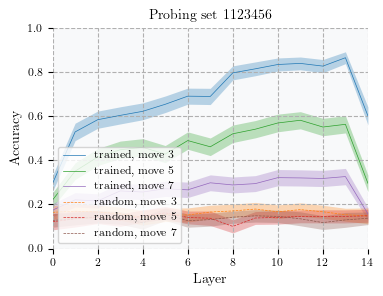

In [37]:
cases = possibilities

for case in cases:
    probing_study = ProbingStudy(case_number=case, tag_name='pv7_n')
    print(probing_study.n_examples)
    probing_study.plot_probe_results(filename="paper_probe_results_" + case)

# Double branches

In [21]:
from leela_interp.core.double_branch import DoubleBranchStudy

In [22]:
study = DoubleBranchStudy(puzzlename="nomate2", load_all=True)

123425 4 4


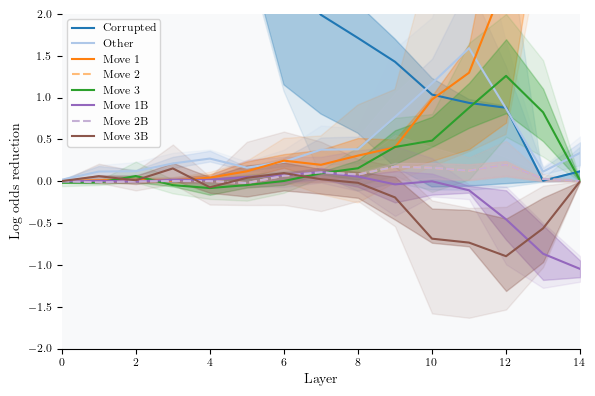

In [23]:
study.plot_residual_effects('b', '123425', filename="paper_residual_effects_123425")